## 1. Imports & Circuit Values

Circuit parameters used to generate the fake data:
- **R** = 1100 Ω
- **L** = 10.46 mH
- **V_max** = 1 V (peak input voltage)
- **Frequency sweep**: 200 Hz – 200 000 Hz

Known capacitances for comparison after back-calculation:
| Label | C (µF) | Expected f₀ (Hz) |
|---|---|---|
| C1uF | 1.0 | 1299.5 |
| C2_2uF | 2.2 | 876.1 |
| C4_7uF | 4.7 | 599.4 |
| C10uF | 10.0 | 410.9 |

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Circuit values
R     = 1100      # ohms
L     = 10.46e-3     # henries
V_max = 1.0       # volts (peak input)

# Known capacitances for comparison (label -> farads)
KNOWN_C = {
    "C5_7pF":   5.7e-12,
    "C6.3pF": 6.3e-12,
    "C8.5pF":  8.5e-12,
    "C11.9pF": 11.9e-12,
    "C32.6pF": 32.6e-12,
    "C69.1nF": 69.1e-9,
    "C102.1pF": 102.1e-12,
    "C0.481nF": 481e-12
}

## 2. Load Data Files

Scans  for all  files.  
In the real project this folder will contain several thousand files — the glob approach handles that automatically.

In [22]:
DATA_DIR = Path("real_data")

files = sorted(DATA_DIR.glob("rlc_sweep_*.csv"))
print(f"Found {len(files)} files:")
for f in files:
    print(" ", f.name)

# Load all into a dict keyed by file stem
data = {f.stem: pd.read_csv(f) for f in files}

Found 8 files:
  rlc_sweep_C102.1pF.csv
  rlc_sweep_C11.9pF.csv
  rlc_sweep_C32.6pF.csv
  rlc_sweep_C481pF.csv
  rlc_sweep_C5.7pF.csv
  rlc_sweep_C6.3pF.csv
  rlc_sweep_C69.1nF.csv
  rlc_sweep_C8.5pF.csv


## 3. Plot All Files

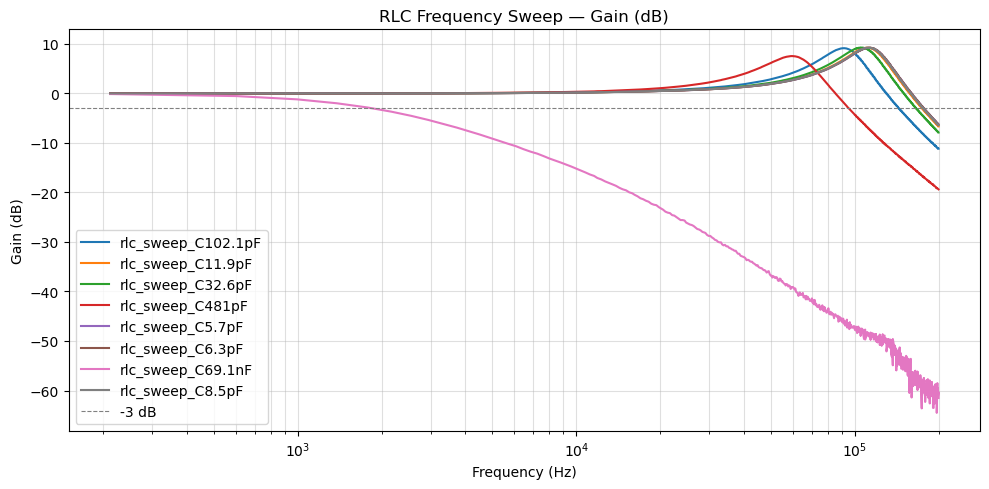

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))

for name, df in data.items():
    ax.semilogx(df["frequency_hz"], df["gain_db"], label=name)

ax.axhline(-3, color="gray", linestyle="--", linewidth=0.8, label="-3 dB")
ax.set_title("RLC Frequency Sweep — Gain (dB)")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Gain (dB)")
ax.legend()
ax.grid(True, which="both", alpha=0.4)
plt.tight_layout()
plt.show()

## 4. Find Peak Frequency for Each File

The frequency at which gain is maximum is the resonant frequency f₀.

In [24]:
peaks = {}
for name, df in data.items():
    idx = df["gain_db"].idxmax()
    peaks[name] = df.loc[idx, "frequency_hz"]

peak_df = pd.DataFrame.from_dict(peaks, orient="index", columns=["peak_freq_hz"])
peak_df.index.name = "file"
peak_df

,peak_freq_hz
file,
rlc_sweep_C102.1pF,90900.0
rlc_sweep_C11.9pF,110000.0
rlc_sweep_C32.6pF,105000.0
rlc_sweep_C481pF,59200.0
rlc_sweep_C5.7pF,112000.0
rlc_sweep_C6.3pF,112000.0
rlc_sweep_C69.1nF,212.0
rlc_sweep_C8.5pF,112000.0


## 5. Back-Calculate Capacitance

Using the resonant frequency formula:  
**f₀ = 1 / (2π √(LC))**  
→ **C = 1 / (L · (2π f₀)²)**

In [25]:
rows = []
for name, f0 in peaks.items():
    C_calc = 1 / (L * (2 * np.pi * f0) ** 2)
    label  = name.replace("rlc_sweep_", "")
    C_known = KNOWN_C.get(label, None)
    rows.append({
        "file":          name,
        "peak_freq_hz":  f0,
        "C_calculated_pF": round(C_calc * 1e12, 4),
        "C_known_pF":    round(C_known * 1e12, 4) if C_known else None,
        "error_%":       round(abs(C_calc - C_known) / C_known * 100, 2) if C_known else None,
    })

pd.DataFrame(rows)

,file,peak_freq_hz,C_calculated_pF,C_known_pF,error_%
0,rlc_sweep_C102.1pF,90900.0,2.930764e+02,102.1,187.05
1,rlc_sweep_C11.9pF,110000.0,2.001351e+02,11.9,1581.81
2,rlc_sweep_C32.6pF,105000.0,2.196494e+02,32.6,573.77
3,rlc_sweep_C481pF,59200.0,6.909795e+02,NaN,NaN
4,rlc_sweep_C5.7pF,112000.0,1.930512e+02,NaN,NaN
5,rlc_sweep_C6.3pF,112000.0,1.930512e+02,6.3,2964.30
6,rlc_sweep_C69.1nF,212.0,5.388115e+07,69100.0,77875.62
7,rlc_sweep_C8.5pF,112000.0,1.930512e+02,8.5,2171.19
